# Multi-Planet Exoplanet Transit Analysis: Kepler-10b & Kepler-10c
An end-to-end photometric pipeline utilizing **Lightkurve** and Astropy's **Box Least Squares (BLS)** to detect, detrend, refine, and characterize multiple transiting exoplanets from Kepler Long-Cadence (~30 min) and Short-Cadence (~1 min) data.

### 1. Library Imports
Importing necessary modules for transit modeling (`BoxLeastSquares`), astronomical light curve handling (`lightkurve`), numerical arrays (`numpy`), and plotting (`matplotlib`).

In [3]:
import lightkurve as lk
import matplotlib.pyplot as plt
import numpy as np
from astropy.timeseries import BoxLeastSquares
from IPython.display import HTML, display

### 2. Querying Kepler Archive Observations
Querying the MAST archive via `lightkurve.search_lightcurve` for both Long Cadence (LC, 1800s integrations) and Short Cadence (SC, 60s integrations) datasets available for **Kepler-10**.

In [4]:
search_result_long = lk.search_lightcurve('Kepler-10', author = 'Kepler', cadence = 'long')
print("Long cadence light curve data retrieved.")

search_result_short = lk.search_lightcurve('Kepler-10', author = 'Kepler', cadence = 'short')
print("Short cadence light curve data retrieved.")

Long cadence light curve data retrieved.
Short cadence light curve data retrieved.


### 3. Light Curve Metadata
Inspecting observation quarters, exposure times (`exptime`), and target metadata across both cadence collections in a side-by-side table display.

In [5]:
cols = ["mission", "year", "author", "exptime", "target_name"]
df_1 = search_result_long.table[cols].to_pandas()
df_2 = search_result_short.table[cols].to_pandas()

df_1.insert(0, "No.", range(1, len(df_1) + 1))
df_2.insert(0, "No.", range(1, len(df_2) + 1))

html_1 = df_1.to_html(index = False)
html_2 = df_2.to_html(index = False)

display(HTML(f"""
<div style = "display: flex; gap: 25px; align-items: flex-start; overflow-x: auto;">
    <div style = "flex: 1; min-width: 400px; text-align: center;">
        <h4 style = "text-align: center;">Long Cadence ({len(df_1)} products)</h4>
        <div style = "display: flex; justify-content: center;">
            {html_1}
        </div>
    </div>
    <div style = "flex: 1; min-width: 400px;">
        <h4 style = "text-align: center;">Short Cadence ({len(df_2)} products)</h4>
        <div style = "display: flex; justify-content: center; text-align: center;">
            {html_2}
        </div>
</div>
</div>
"""))

No.,mission,year,author,exptime,target_name
1,Kepler Quarter 00,2009,Kepler,1800.0,kplr011904151
2,Kepler Quarter 01,2009,Kepler,1800.0,kplr011904151
3,Kepler Quarter 02,2009,Kepler,1800.0,kplr011904151
4,Kepler Quarter 03,2009,Kepler,1800.0,kplr011904151
5,Kepler Quarter 04,2010,Kepler,1800.0,kplr011904151
6,Kepler Quarter 05,2010,Kepler,1800.0,kplr011904151
7,Kepler Quarter 06,2010,Kepler,1800.0,kplr011904151
8,Kepler Quarter 07,2010,Kepler,1800.0,kplr011904151
9,Kepler Quarter 09,2011,Kepler,1800.0,kplr011904151
10,Kepler Quarter 10,2011,Kepler,1800.0,kplr011904151


### 4. Downloading and Visualizing Raw Light Curves
Downloading all target pixel files/light curves and plotting the raw flux across the ~4-year mission baseline. Notice quarterly offsets and low-frequency stellar variability.

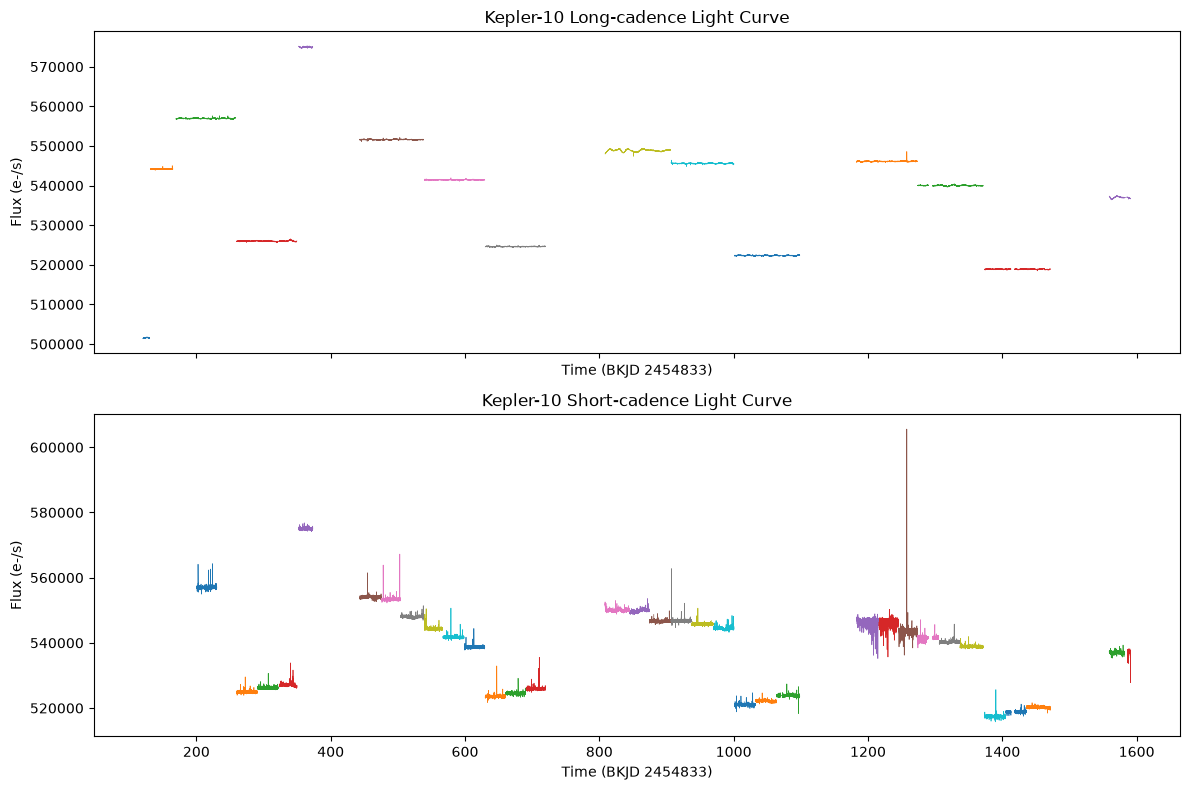

In [6]:
lc_collection_long = search_result_long.download_all()
lc_collection_short = search_result_short.download_all()

fig, ax = plt.subplots(2, 1, figsize = (12, 8), sharex = True)

lc_collection_long.plot(ax = ax[0], label = "Long-cadence light curve")
ax[0].set_title("Kepler-10 Long-cadence Light Curve")
ax[0].set_xlabel("Time (BKJD 2454833)")
ax[0].set_ylabel("Flux (e-/s)")

lc_collection_short.plot(ax = ax[1], label = "Short-cadence light curve")
ax[1].set_title("Kepler-10 Short-cadence Light Curve")
ax[1].set_xlabel("Time (BKJD 2454833)")
ax[1].set_ylabel("Flux (e-/s)")

for aa in ax:
    legend = aa.get_legend()
    if legend is not None:
        legend.remove()

plt.tight_layout()
plt.show()

### 5. Cleaning & Flattening (Detrending)
Before running transit searches, raw light curves must be cleaned and detrended:
* **`stitch().remove_nans().normalize()`**: Combines quarterly segments into continuous relative flux normalized around 1.0.
* **`remove_outliers(sigma_upper = 3, sigma_lower = 6)`**: Asymmetric sigma clipping. Upper threshold ($3\sigma$) removes cosmic ray hits and stellar flares; wider lower threshold ($6\sigma$) protects real transit dips from being clipped.
* **`flatten(window_length = ..., polyorder = 2)`**: Fits a local 2nd-order Savitzky-Golay polynomial over a sliding window to remove stellar variability:
  * **`window_length`**: Filter length in cadence points. For LC ($30\text{ min}$), `241` points $\approx 5\text{ days}$; for SC ($1\text{ min}$), `7201` points $\approx 5\text{ days}$. A window of $\sim 5\text{ days}$ is much wider than transit durations ($<7\text{ hours}$), preventing transits from being smoothed out.

In [7]:
lc_long = lc_collection_long.stitch().remove_nans().normalize()
lc_short = lc_collection_short.stitch().remove_nans().normalize()

lc_long_clean = lc_long.remove_outliers(sigma_upper = 3, sigma_lower = 6)
lc_short_clean = lc_short.remove_outliers(sigma_upper = 3, sigma_lower = 6)

lc_long_flat = lc_long_clean.flatten(window_length = 241, polyorder = 2)
lc_short_flat = lc_short_clean.flatten(window_length = 7201, polyorder = 2)

### 6. Visualizing Detrended Light Curves
Verifying that slow stellar variability has been flattened to a flat baseline of 1.0 while preserving sharp negative transit signals across the full observation timeline.

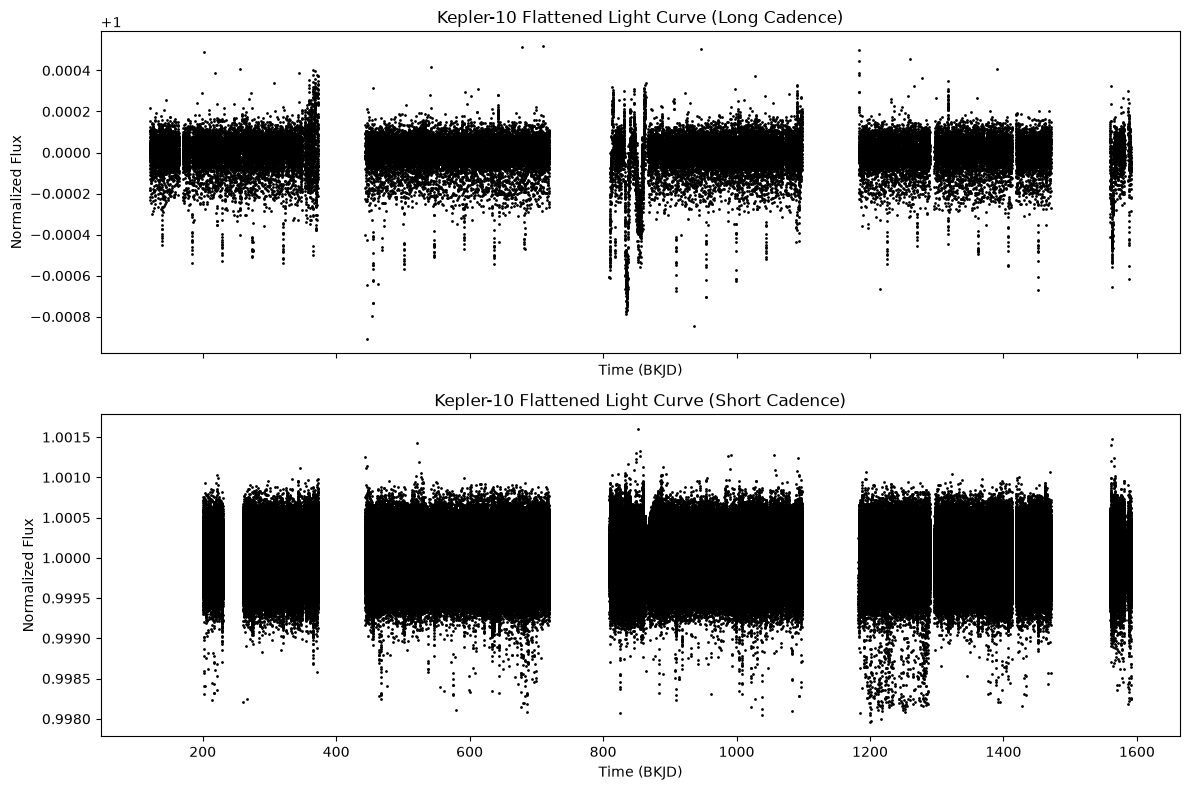

In [8]:
fig, ax = plt.subplots(2, 1, figsize = (12, 8), sharex = True)

lc_long_flat.scatter(ax = ax[0], color = 'black')
ax[0].set_title('Kepler-10 Flattened Light Curve (Long Cadence)')
ax[0].set_xlabel('Time (BKJD)')
ax[0].set_ylabel('Normalized Flux')

lc_short_flat.scatter(ax = ax[1], color = 'black')
ax[1].set_title('Kepler-10 Flattened Light Curve (Short Cadence)')
ax[1].set_xlabel('Time (BKJD)')
ax[1].set_ylabel('Normalized Flux')

for aa in ax:
    legend = aa.get_legend()
    if legend is not None:
        legend.remove()
        
plt.tight_layout()
plt.show()

### 7. Primary Planet Search (Kepler-10b): BLS Setup
Setting up a **Box Least Squares (BLS)** search on the flattened long-cadence data:
* **`durations_long`**: Grid of trial transit durations ($0.05$ to $0.4$ days $\approx 1.2$ to $9.6$ hours).
* **`autoperiod(minimum_period = 0.5, maximum_period = 50)`**: Generates an optimal frequency grid spacing requiring at least 3 transits over the baseline.
* **`frequency_factor=50`**: Oversamples the standard Fourier frequency grid to ensure narrow transit peaks are not missed between grid points.

In [9]:
time_long = lc_long_flat.time.value
flux_long = lc_long_flat.flux.value
flux_err_long = lc_long_flat.flux_err.value

bls_long = BoxLeastSquares(time_long, flux_long, dy = flux_err_long)

durations_long = np.linspace(0.05, 0.4, 100)

periods_long = bls_long.autoperiod(
    duration = durations_long,
    minimum_period = 0.5,
    maximum_period = 50,
    minimum_n_transit = 3,
    frequency_factor = 50
)

### 8. Coarse Detection of Kepler-10b
Evaluating the BLS periodogram power across all periods and durations, locating the highest power peak to determine initial period, duration, and transit depth for the primary planet.

In [10]:
results_long = bls_long.power(
    periods_long,
    durations_long,
    oversample = 10
)

index = np.argmax(results_long.power)

b_vals_long = {
    "period": results_long.period[index],
    "duration": results_long.duration[index],
    "depth": results_long.depth[index],
    "power": results_long.power[index],
    "transit_time": results_long.transit_time[index]
}

print(f"Coarse period for 10b: {b_vals_long['period']:.6f} days")
print(f"Coarse duration for 10b: {b_vals_long['duration']:.3f} days")
print(f"Coarse depth for 10b: {b_vals_long['depth'] * 1e6:.0f} ppm")

Coarse period for 10b: 0.837490 days
Coarse duration for 10b: 0.070 days
Coarse depth for 10b: 163 ppm


### 9. High-Resolution Short-Cadence Parameter Refinement (10b)
Using 1-minute short-cadence data to refine parameters around the coarse period (10,000 period points over $\pm 0.01\text{ days}$ across 50 duration slices):
* **`oversample = 20`**: Phase bins are oversampled to resolve ingress and egress transitions with high timing precision.

In [11]:
time_short = lc_short_flat.time.value
flux_short = lc_short_flat.flux.value
flux_err_short = lc_short_flat.flux_err.value

bls_short = BoxLeastSquares(time_short, flux_short, dy = flux_err_short)

periods_short = np.linspace(b_vals_long['period'] - 0.01, b_vals_long['period'] + 0.01, 10000)
durations_short = np.linspace(b_vals_long['duration'] - 0.01, b_vals_long['duration'] + 0.01, 50)

power_max = -np.inf

for i, duration in enumerate(durations_short, start = 1):
    results_short = bls_short.power(
        periods_short,
        duration,
        oversample=20
    )

    best_index = np.argmax(results_short.power)
    power = results_short.power[best_index]
    
    if power > power_max:
        b_vals_refined = {
            'period': results_short.period[best_index],
            'duration': duration,
            'depth': results_short.depth[best_index],
            'power': power,
            'transit_time': results_short.transit_time[best_index]
        }

        b_results_refined = results_short

        power_max = power

    if i % 10 == 0:
        print(f"Refining transit parameters: {i}/{len(durations_short)} durations tested")

print(f"\nRefined period for 10b: {b_vals_refined['period']:.6f} days") # 0 s
print(f"Refined duration for 10b: {b_vals_refined['duration']:.3f} days") # 2.88 mins
print(f"Refined depth for 10b: {b_vals_refined['depth'] * 1e6:.0f} ppm")

Refining transit parameters: 10/50 durations tested
Refining transit parameters: 20/50 durations tested
Refining transit parameters: 30/50 durations tested
Refining transit parameters: 40/50 durations tested
Refining transit parameters: 50/50 durations tested

Refined period for 10b: 0.837491 days
Refined duration for 10b: 0.073 days
Refined depth for 10b: 168 ppm


### 10. Kepler-10b BLS Periodogram
Plotting BLS power vs. orbital period around the peak. Kepler-10b completed $>1{,}700$ orbits over the Kepler mission, producing an extremely narrow, high-significance resonance spike at $P \approx 0.837491\text{ days}$.

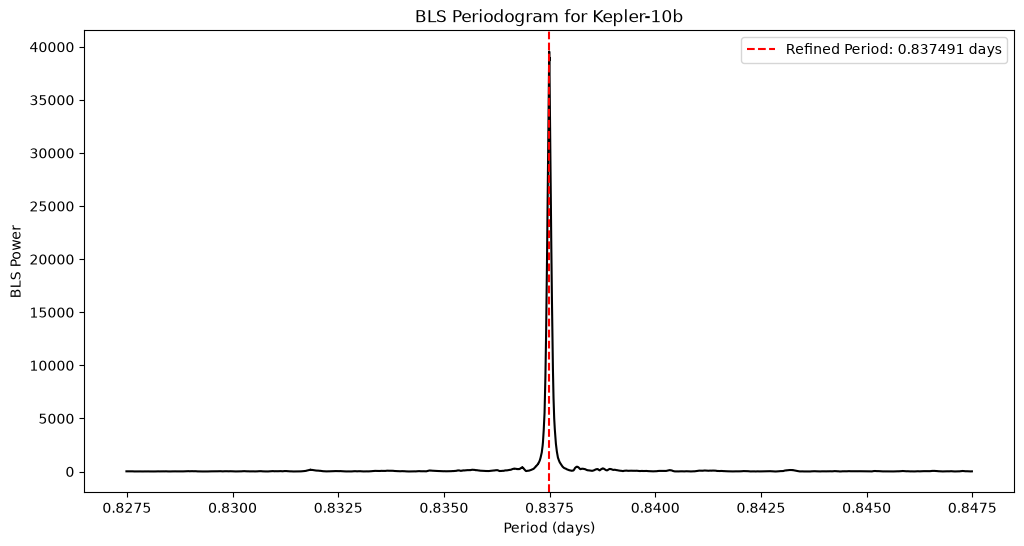

In [12]:
plt.figure(figsize = (12, 6))

plt.plot(b_results_refined.period, b_results_refined.power, color = 'black')

plt.axvline(b_vals_refined['period'], color = 'red', linestyle = '--', label = f"Refined Period: {b_vals_refined['period']:.6f} days")

plt.title('BLS Periodogram for Kepler-10b')
plt.xlabel('Period (days)')
plt.ylabel('BLS Power')

plt.legend()
plt.show()

### 11. Phase-Folded Transit (Short Cadence) - Kepler-10b
Phase-folding short-cadence observations on the refined period ($0.837491\text{ d}$) and transit epoch ($t_0$), overlaid with the best-fit BLS box model.

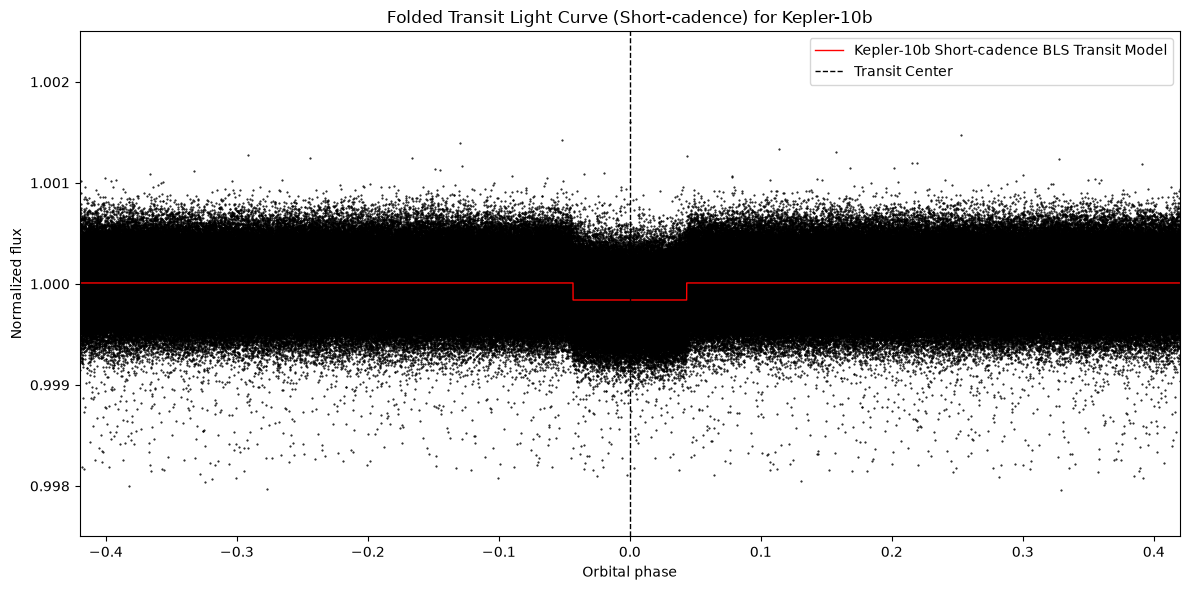

In [13]:
planet_b_model = bls_short.model(
    time_short,
    b_vals_refined['period'],
    b_vals_refined['duration'],
    b_vals_refined['transit_time']
)

planet_b_model_lc = lk.LightCurve(time=time_short, flux = planet_b_model)

fig, ax = plt.subplots(figsize = (12, 6))

lc_short_flat.fold(b_vals_refined["period"], b_vals_refined["transit_time"], normalize_phase = True).scatter(ax = ax, color = "black", s = 1, label = "_nolegend_")
planet_b_model_lc.fold(b_vals_refined["period"], b_vals_refined["transit_time"], normalize_phase = True).plot(ax = ax, color = "red", lw = 1, label = "Kepler-10b Short-cadence BLS Transit Model")

ax.axvline(0, color = "black", linestyle = "--", linewidth = 1, label = "Transit Center")

ax.set_title("Folded Transit Light Curve (Short-cadence) for Kepler-10b")
ax.set_xlabel("Orbital phase")
ax.set_ylabel("Normalized flux")

plt.xlim(-0.42, 0.42)
plt.ylim(0.9975, 1.0025)

plt.legend(loc = "upper right")
fig.tight_layout()
plt.show()

### 12. Phase-Folded Transit (Long Cadence) - Kepler-10b
Phase-folding long-cadence data on the coarse model for comparison. The 30-minute integration slightly smooths the ingress and egress compared to short cadence.

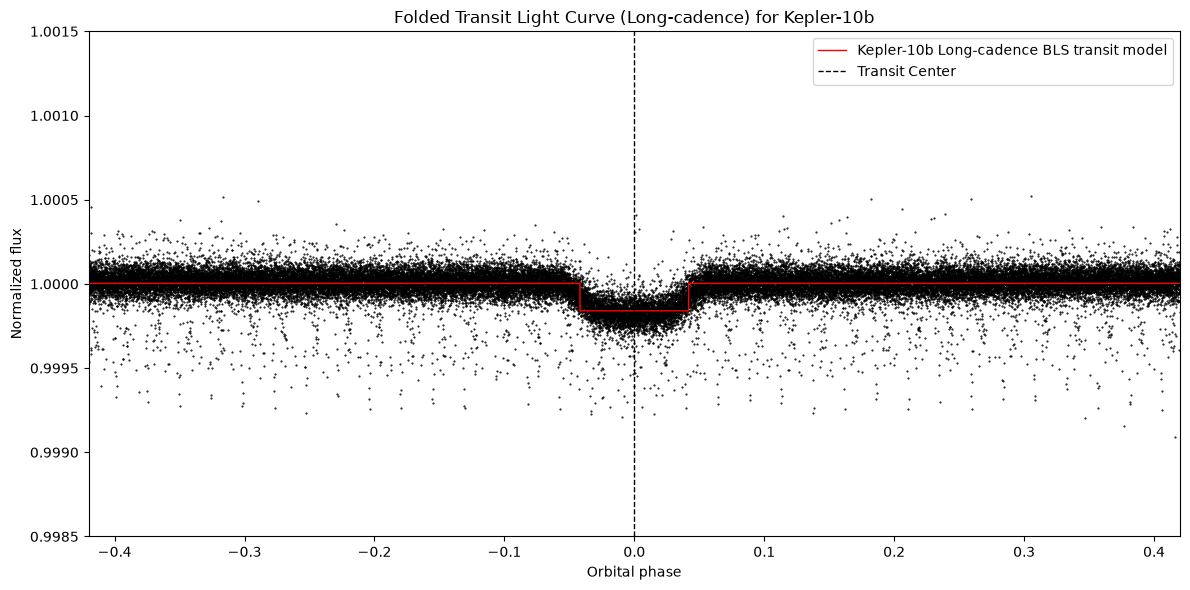

In [14]:
planet_b_coarse_model = bls_long.model(
    time_long,
    b_vals_long["period"],
    b_vals_long["duration"],
    b_vals_long["transit_time"]
)

planet_b_coarse_model_lc = lk.LightCurve(time=time_long,flux=planet_b_coarse_model)

fig, ax = plt.subplots(figsize = (12, 6))

lc_long_flat.fold(b_vals_long["period"], b_vals_long["transit_time"], normalize_phase = True).scatter(ax = ax,color = "black", s = 1, label = "_nolegend_")
planet_b_coarse_model_lc.fold(b_vals_long["period"], b_vals_long["transit_time"], normalize_phase = True).plot(ax = ax, color = "red", lw = 1, label = "Kepler-10b Long-cadence BLS transit model")

ax.axvline(0, color = "black", linestyle = "--", linewidth = 1, label = "Transit Center")

ax.set_title("Folded Transit Light Curve (Long-cadence) for Kepler-10b")
ax.set_xlabel("Orbital phase")
ax.set_ylabel("Normalized flux")

plt.xlim(-0.42, 0.42)
plt.ylim(0.9985, 1.0015)

ax.legend(loc = "upper right")
fig.tight_layout()
plt.show()

### 13. Iterative Multi-Planet Search: Masking Kepler-10b Transits
To search for additional, shallower, or longer-period planets, we remove the dominant signal of Kepler-10b:
* **`bls.transit_mask()`**: Flags all data points falling within Kepler-10b's transit windows.
* Points matching the mask are removed from both long and short cadence sets to produce clean **residual light curves** (`lc_*_residual`).

In [15]:
mask_10b_long = bls_long.transit_mask(
    t = time_long,
    period=b_vals_refined['period'],
    duration=b_vals_refined['duration'],
    transit_time=b_vals_refined['transit_time']
)

lc_long_residual = lc_long_flat[~mask_10b_long]

mask_10b_short = bls_short.transit_mask(
    t = time_short,
    period=b_vals_refined['period'],
    duration=b_vals_refined['duration'],
    transit_time=b_vals_refined['transit_time']
)

lc_short_residual = lc_short_flat[~mask_10b_short]

### 14. Secondary Planet Search (Kepler-10c): BLS Setup on Residuals
Re-initializing Box Least Squares on the residual long-cadence data (`lc_long_residual`), scanning periods from 1 to 50 days with trial durations from $0.1$ to $0.4$ days.

In [16]:
time_long_residual = lc_long_residual.time.value
flux_long_residual = lc_long_residual.flux.value
flux_err_long_residual = lc_long_residual.flux_err.value

bls_long_residual = BoxLeastSquares(time_long_residual, flux_long_residual, dy = flux_err_long_residual)

durations_long_residual = np.linspace(0.1, 0.4, 100)

periods_long_residual = bls_long_residual.autoperiod(
    duration = durations_long_residual,
    minimum_period = 1,
    maximum_period = 50,
    minimum_n_transit = 3,
    frequency_factor = 50
)

### 15. Coarse Detection of Kepler-10c
Computing BLS power across the residual dataset. A strong peak emerges at $P \approx 45.29\text{ days}$ with a depth of $\sim 388\text{ ppm}$, corresponding to the secondary planet **Kepler-10c**.

In [17]:
results_long_residual = bls_long_residual.power(
    periods_long_residual,
    durations_long_residual,
    oversample=10
)

index_residual = np.argmax(results_long_residual.power)

c_vals_long = {
    "period": results_long_residual.period[index_residual],
    "duration": results_long_residual.duration[index_residual],
    "depth": results_long_residual.depth[index_residual],
    "power": results_long_residual.power[index_residual],
    "transit_time": results_long_residual.transit_time[index_residual]
}

print(f"Coarse period for 10c: {c_vals_long['period']:.6f} days")
print(f"Coarse duration for 10c: {c_vals_long['duration']:.3f} days")
print(f"Coarse depth for 10c: {c_vals_long['depth'] * 1e6:.0f} ppm")

Coarse period for 10c: 45.292362 days
Coarse duration for 10c: 0.250 days
Coarse depth for 10c: 388 ppm


### 16. High-Resolution Refinement for Kepler-10c on Short Cadence
Refining the period and duration of Kepler-10c using short-cadence residuals (`lc_short_residual`) across a tight grid (10,000 periods and 50 duration slices).

In [18]:
time_short_residual = lc_short_residual.time.value
flux_short_residual = lc_short_residual.flux.value
flux_err_short_residual = lc_short_residual.flux_err.value

bls_short_residual = BoxLeastSquares(time_short_residual, flux_short_residual, dy = flux_err_short_residual)

periods_short_residual = np.linspace(c_vals_long['period'] - 0.01, c_vals_long['period'] + 0.01, 10000)
durations_short_residual = np.linspace(c_vals_long['duration'] - 0.1, c_vals_long['duration'] + 0.1, 50)

power_max = -np.inf

for i, duration in enumerate(durations_short_residual, start = 1):
    results_short_residual = bls_short_residual.power(
        periods_short_residual,
        duration,
        oversample=20
    )

    best_index = np.argmax(results_short_residual.power)
    power = results_short_residual.power[best_index]
    
    if power > power_max:
        c_vals_refined = {
            'period': results_short_residual.period[best_index],
            'duration': duration,
            'depth': results_short_residual.depth[best_index],
            'power': power,
            'transit_time': results_short_residual.transit_time[best_index]
        }

        c_results_refined = results_short_residual

        power_max = power

    if i % 10 == 0:
        print(f"Refining transit parameters: {i}/{len(durations_short_residual)} durations tested")

print(f"\nRefined period for 10c: {c_vals_refined['period']:.6f} days") # 4.58 s
print(f"Refined duration for 10c: {c_vals_refined['duration']:.3f} days") # 25.92 mins
print(f"Refined depth for 10c: {c_vals_refined['depth'] * 1e6:.0f} ppm")

Refining transit parameters: 10/50 durations tested
Refining transit parameters: 20/50 durations tested
Refining transit parameters: 30/50 durations tested
Refining transit parameters: 40/50 durations tested
Refining transit parameters: 50/50 durations tested

Refined period for 10c: 45.294248 days
Refined duration for 10c: 0.268 days
Refined depth for 10c: 380 ppm


### 17. Kepler-10c BLS Periodogram
Plotting the periodogram for Kepler-10c. Because 10c orbits every $\sim 45.3\text{ days}$, only $\sim 30$ transits occurred over the mission, giving a broader peak envelope compared to 10b.

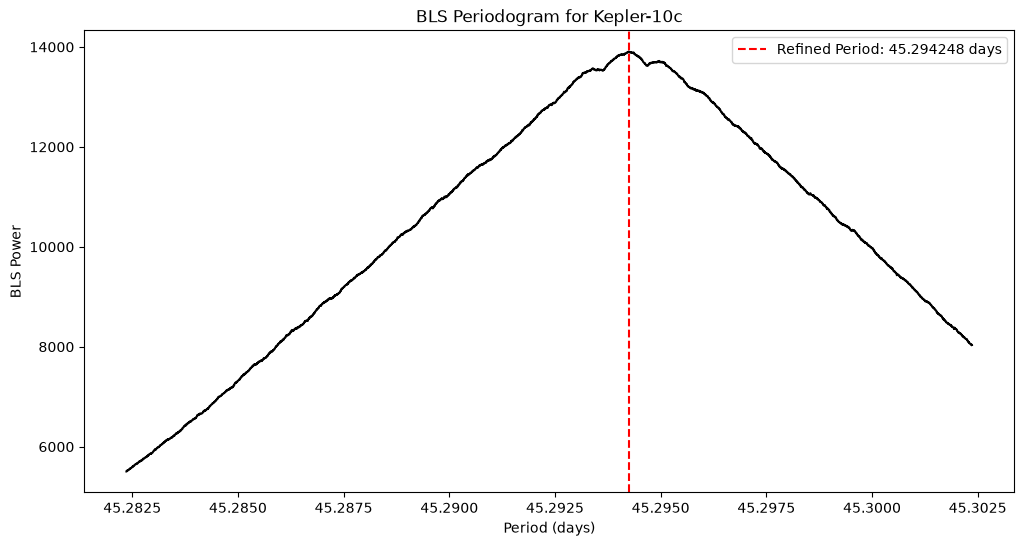

In [19]:
plt.figure(figsize = (12, 6))

plt.plot(c_results_refined.period, c_results_refined.power, color = 'black')

plt.axvline(c_vals_refined['period'], color='red', linestyle = '--', label = f"Refined Period: {c_vals_refined['period']:.6f} days")

plt.title('BLS Periodogram for Kepler-10c')
plt.xlabel('Period (days)')
plt.ylabel('BLS Power')

plt.legend()
plt.show()

### 18. Phase-Folded Transit (Short Cadence) - Kepler-10c
Phase-folding the short-cadence residual light curve on the refined period ($45.294248\text{ d}$) zoomed into the transit window (`xlim=(-0.03, 0.03)`). With Kepler-10b masked out, the $\sim 380\text{ ppm}$ transit profile is cleanly isolated.

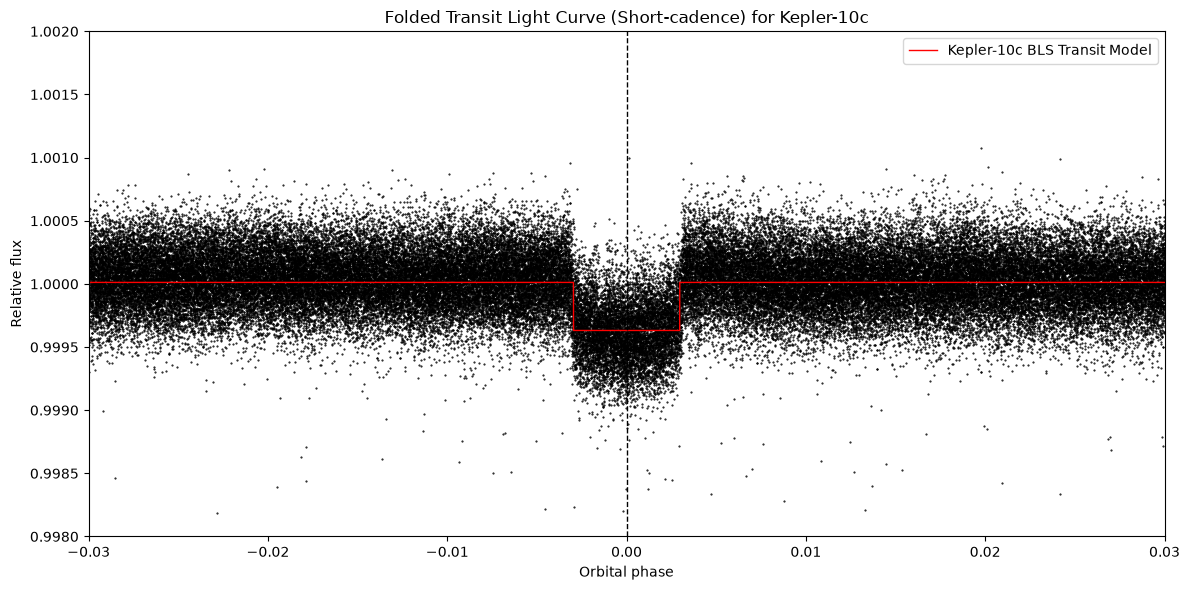

In [20]:
planet_c_model = bls_short_residual.model(
    time_short_residual,
    c_vals_refined['period'],
    c_vals_refined['duration'],
    c_vals_refined['transit_time']
)

planet_c_model_lc = lk.LightCurve(time=time_short_residual, flux=planet_c_model)

fig, ax = plt.subplots(figsize=(12, 6))

lc_short_residual.fold(c_vals_refined["period"], c_vals_refined["transit_time"], normalize_phase = True).scatter(ax=ax, color="black", s=1, label="_nolegend_")
planet_c_model_lc.fold(c_vals_refined["period"], c_vals_refined["transit_time"], normalize_phase = True).plot(ax=ax, color="red", lw=1, label="Kepler-10c BLS Transit Model")

ax.axvline(0, color="black", linestyle="--", linewidth=1)

ax.set_title("Folded Transit Light Curve (Short-cadence) for Kepler-10c")
ax.set_xlabel("Orbital phase")
ax.set_ylabel("Relative flux")

plt.xlim(-0.03, 0.03)
plt.ylim(0.998, 1.002)

ax.legend(loc = "upper right")
fig.tight_layout()
plt.show()

### 19. Phase-Folded Transit (Long Cadence) - Kepler-10c
Phase-folding the long-cadence residual data on the coarse model for comparison across the 45-day orbit.

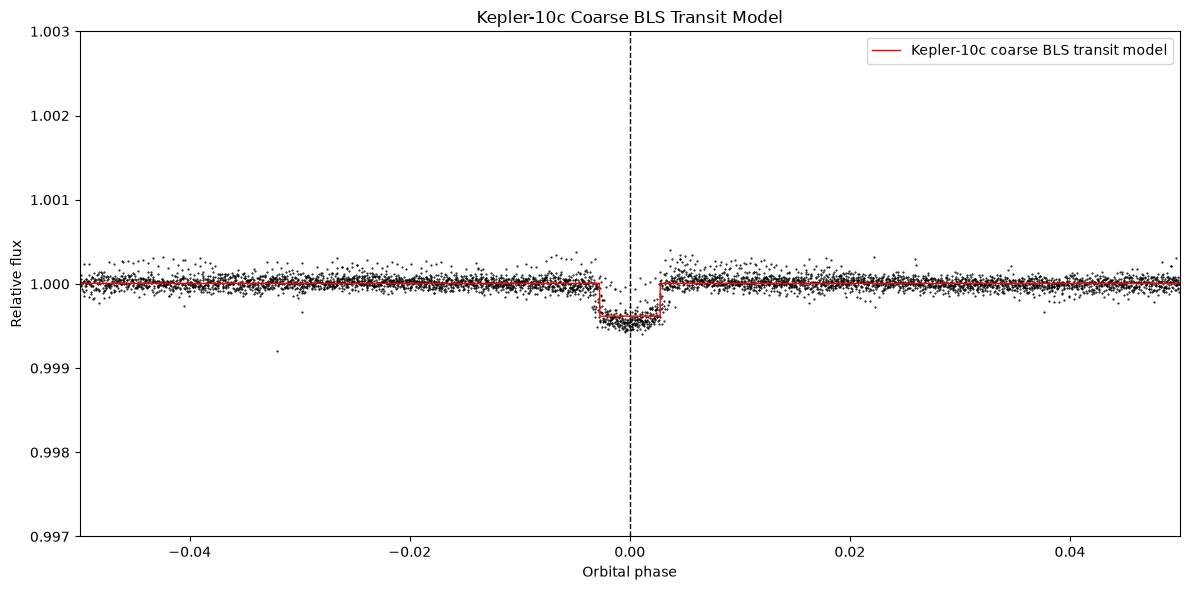

In [21]:
planet_c_coarse_model = bls_long_residual.model(
    time_long_residual,
    c_vals_long["period"],
    c_vals_long["duration"],
    c_vals_long["transit_time"]
)

planet_c_coarse_model_lc = lk.LightCurve(time = time_long_residual,flux = planet_c_coarse_model)

fig, ax = plt.subplots(figsize = (12, 6))

lc_long_residual.fold(c_vals_long["period"], c_vals_long["transit_time"], normalize_phase = True).scatter(ax = ax,color = "black", s = 1, label = "_nolegend_")
planet_c_coarse_model_lc.fold(c_vals_long["period"], c_vals_long["transit_time"], normalize_phase = True).plot(ax = ax, color = "red", lw = 1, label = "Kepler-10c coarse BLS transit model")

ax.axvline(0, color = "black", linestyle = "--", linewidth = 1)

ax.set_title("Kepler-10c Coarse BLS Transit Model")
ax.set_xlabel("Orbital phase")
ax.set_ylabel("Relative flux")

plt.xlim(-0.05, 0.05)
plt.ylim(0.997, 1.003)

ax.legend(loc = "upper right")
fig.tight_layout()
plt.show()